# Embedding with htsne and humap

How to call mixle's model-based embeddings. `htsne` and `humap` fit a mixture model to heterogeneous data, turn the posteriors into pairwise affinities, and lay them out in 2-D with t-SNE / UMAP respectively. This is the syntax tutorial; for the affinity theory and failure modes see the data-science notebook model_based_embeddings, and for a real case study see malware_certificate_embedding.


In [1]:
import io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from mixle.stats import (GaussianDistribution, CategoricalDistribution, PoissonDistribution,
                        BernoulliSetDistribution, CompositeDistribution, OptionalDistribution)
from mixle.utils.hvis import htsne, humap

# a labelled mixture of HETEROGENEOUS records: a real value, a category,
# a set of tags, and a sometimes-missing count -- four different field types
TAGS = ['a', 'b', 'c', 'd']
def make_record_groups(seed=1, per=40):
    rng = np.random.RandomState(seed)
    comps = [CompositeDistribution((GaussianDistribution(3.0 * k, 1.0),
                                    CategoricalDistribution({'x': [0.8, 0.34, 0.1][k], 'y': [0.1, 0.33, 0.1][k], 'z': [0.1, 0.33, 0.8][k]}),
                                    BernoulliSetDistribution({t: (0.8 if (i % 4) == k else 0.15) for i, t in enumerate(TAGS)}),
                                    OptionalDistribution(PoissonDistribution(2.0 + 3 * k), p=0.2)))
             for k in range(3)]
    data, labels = [], []
    for k, comp in enumerate(comps):
        s = comp.sampler(seed=rng.randint(2**31))
        for _ in range(per):
            data.append(s.sample()); labels.append(k)
    return data, np.asarray(labels)

data, labels = make_record_groups()
print('%d records, each = (real, category, tag-set, maybe-missing count); e.g. %r' % (len(data), data[0]))

120 records, each = (real, category, tag-set, maybe-missing count); e.g. (0.9255484720974448, 'x', ['a'], 1)


## `htsne(data)` - the one-call embedding

Pass the raw heterogeneous records. `htsne` fits the model, computes affinities, and returns an `(n, 2)` array. `out=` captures the fitting log; `seed=` and `perplexity=` control the t-SNE layout.


/private/tmp/nb-070-venv/lib/python3.12/site-packages/mixle/stats/univariate/continuous/generalized_gaussian.py:108: RuntimeWarning: overflow encountered in power
  return self._log_norm - z**self.beta
/private/tmp/nb-070-venv/lib/python3.12/site-packages/mixle/stats/bayes/dirichlet_process_mixture.py:293: RuntimeWarning: invalid value encountered in multiply
  rv += np.sum(phi * (exp_ll - self.log_w), axis=1)


embedding shape: (120, 2)


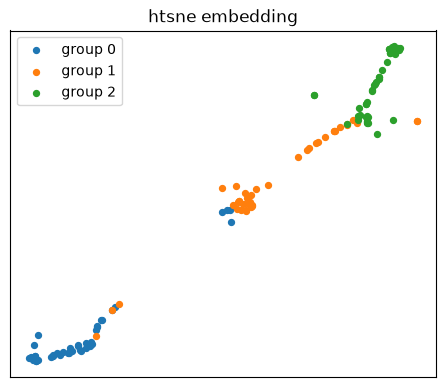

In [2]:
emb = htsne(data, seed=1, perplexity=20, out=io.StringIO())
print('embedding shape:', emb.shape)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for k in range(3):
    m = labels == k
    ax.scatter(emb[m, 0], emb[m, 1], s=18, label='group %d' % k)
ax.set_title('htsne embedding'); ax.set_xticks([]); ax.set_yticks([]); ax.legend()
plt.show()

## `humap(data)` - the UMAP layout

Same affinities, different layout engine. Takes `n_neighbors=` instead of `perplexity=`.


In [3]:
um = humap(data, seed=1, n_neighbors=15, out=io.StringIO())
print('humap shape:', um.shape)

/private/tmp/nb-070-venv/lib/python3.12/site-packages/mixle/stats/univariate/continuous/generalized_gaussian.py:108: RuntimeWarning: overflow encountered in power
  return self._log_norm - z**self.beta
/private/tmp/nb-070-venv/lib/python3.12/site-packages/mixle/stats/bayes/dirichlet_process_mixture.py:293: RuntimeWarning: invalid value encountered in multiply
  rv += np.sum(phi * (exp_ll - self.log_w), axis=1)


humap shape: (120, 2)


## Choosing the affinity

The embedding is only as good as the pairwise affinity it lays out, and `htsne` offers several ways to turn the fitted mixture's per-point posteriors into affinities:

| `affinity=` | what two points are "close" means |
|---|---|
| `'auto'` (default) | the per-field, evidence-capped posterior overlap - robust across heterogeneous fields |
| `'bhattacharyya'` | distributional overlap of the two points' component-posteriors (Bhattacharyya coefficient) |
| `'coassign'` | probability the two points are assigned to the same mixture component |
| `'fisher'` | distance in the model's Fisher information metric (local curvature of the likelihood) |

They can produce visibly different maps from the same fitted model. Below, the same heterogeneous records under each affinity - colour is the true group.


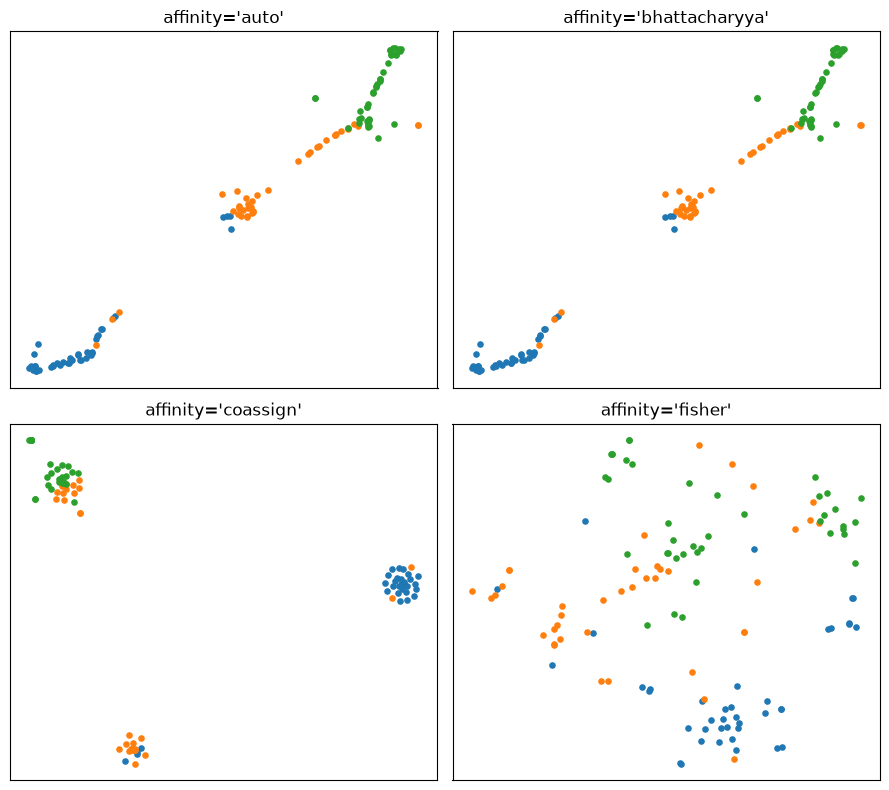

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, aff in zip(axes.ravel(), ['auto', 'bhattacharyya', 'coassign', 'fisher']):
    Y = htsne(data, seed=1, perplexity=20, affinity=aff, out=io.StringIO())
    for k in range(3):
        m = labels == k
        ax.scatter(Y[m, 0], Y[m, 1], s=14)
    ax.set_title("affinity='%s'" % aff); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

### Reusing a fitted model

`htsne` fits a mixture internally, but you can supply your own with `mix_model=` - useful to embed several datasets in a comparable space, or to reuse an expensive fit. Pass any fitted `mixle.stats` mixture; the affinities are computed from its posteriors.


In [5]:
from mixle.stats import (MixtureEstimator, CompositeEstimator, GaussianEstimator,
                        CategoricalEstimator, BernoulliSetEstimator, OptionalEstimator, PoissonEstimator)
from mixle.inference.estimation import optimize
comp = CompositeEstimator((GaussianEstimator(), CategoricalEstimator(),
                           BernoulliSetEstimator(), OptionalEstimator(PoissonEstimator())))
mix = optimize(data, MixtureEstimator([comp] * 3), max_its=30, rng=np.random.RandomState(0), out=io.StringIO())
Y = htsne(data, seed=1, perplexity=20, mix_model=mix, out=io.StringIO())
print('embedded with a supplied 3-component mixture ->', Y.shape)

embedded with a supplied 3-component mixture -> (120, 2)


## Is the map telling the truth? `embedding_health` (new in mixle 0.7.0)

A 2-D embedding is a lossy projection, and "it looks clustered" is not a measurement — a bad map can
look just as tidy as a good one. mixle 0.7.0 adds `embedding_health`, a **rendering-fidelity receipt**
that scores the map against the *model's* affinity, not against the pixels:

* **trustworthiness** — are points that look close on the map genuinely close under the model? (Low ⇒
  the map invents neighbors that aren't real.)
* **continuity** — are points the model considers close kept close on the map? (Low ⇒ the map tears
  real neighborhoods apart.)

Both live in `[0, 1]`, and a `diagnosis` list spells out any failure in words. To show it earns its
keep, we score three maps of the *same* data: a well-optimized htsne, a deliberately under-optimized
one (stopped after 5 iterations), and a random scatter.

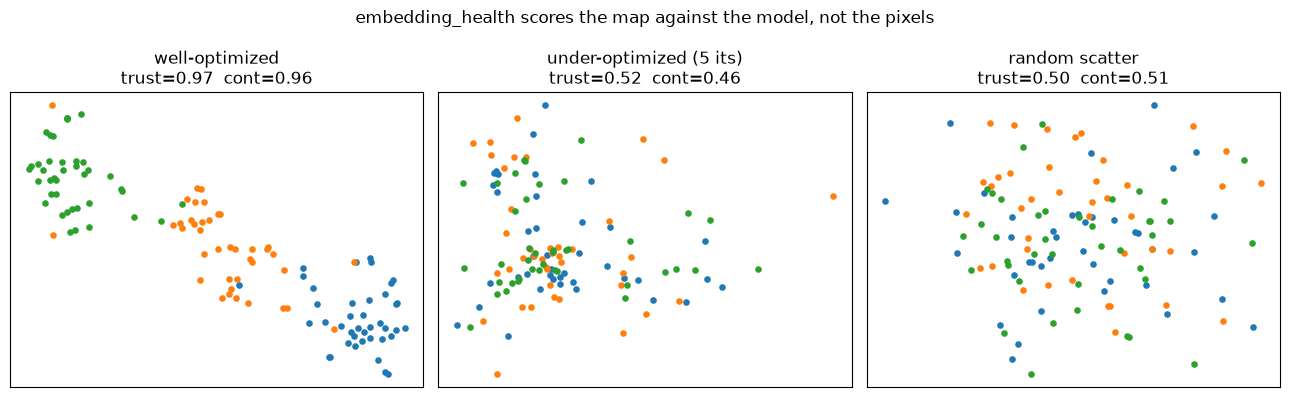

In [6]:
from mixle.utils.hvis import embedding_health

good   = htsne(data, seed=1, perplexity=20, mix_model=mix, max_its=1000, out=io.StringIO())
undercooked = htsne(data, seed=1, perplexity=20, mix_model=mix, max_its=5, out=io.StringIO())
scramble = np.random.RandomState(0).randn(len(data), 2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, Y, title in zip(axes, [good, undercooked, scramble],
                        ['well-optimized', 'under-optimized (5 its)', 'random scatter']):
    h = embedding_health(Y, mix, data)
    for k in range(3):
        m = labels == k
        ax.scatter(Y[m, 0], Y[m, 1], s=14)
    ax.set_title('%s\ntrust=%.2f  cont=%.2f' % (title, h['trustworthiness'], h['continuity']))
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('embedding_health scores the map against the model, not the pixels'); fig.tight_layout(); plt.show()

In [7]:
# The receipt doesn't just score -- it says what went wrong, in words you can act on.
for name, Y in [('well-optimized', good), ('under-optimized', undercooked), ('random scatter', scramble)]:
    h = embedding_health(Y, mix, data)
    print('%-18s trust=%.3f  cont=%.3f' % (name, h['trustworthiness'], h['continuity']))
    for line in h['diagnosis']:
        print('   -', line)

well-optimized     trust=0.968  cont=0.964
under-optimized    trust=0.522  cont=0.459
   - trustworthiness 0.52: the map shows neighbor pairs the model does not support -- treat visual proximity with suspicion (bad init, unconverged refine, or a topology 2-D cannot hold).
   - continuity 0.46: genuinely-close pairs (under the model) were torn apart in the map -- clusters or fibers may be split visually that the model considers one region.
random scatter     trust=0.498  cont=0.514
   - trustworthiness 0.50: the map shows neighbor pairs the model does not support -- treat visual proximity with suspicion (bad init, unconverged refine, or a topology 2-D cannot hold).
   - continuity 0.51: genuinely-close pairs (under the model) were torn apart in the map -- clusters or fibers may be split visually that the model considers one region.


The well-optimized map scores ~0.97 on both and reports no issues; the under-optimized and random
maps collapse to ~0.5 and the diagnosis names the failure ("the map shows neighbor pairs the model
does not support -- treat visual proximity with suspicion"). That is the point: you can now **reject a
misleading embedding by number**, instead of trusting a layout because it happens to look neat.

## Guiding the layout with goals — and verifying it stayed honest (new in mixle 0.7.0)

`goals` are soft objectives that organize a map toward structure you already know. `LabelCohesion`
pulls same-label points toward their label's centroid. This is **supervised guidance, not label
discovery**: it enforces labels you supply — it does not infer them. The natural worry is that
forcing structure *distorts* the geometry — so we guide the map with known labels, then use the
`embedding_health` receipt from above to confirm the fidelity held.

We build a fresh set of four **overlapping** classes, where the unsupervised map genuinely muddles
them, and hand `LabelCohesion` the true labels.

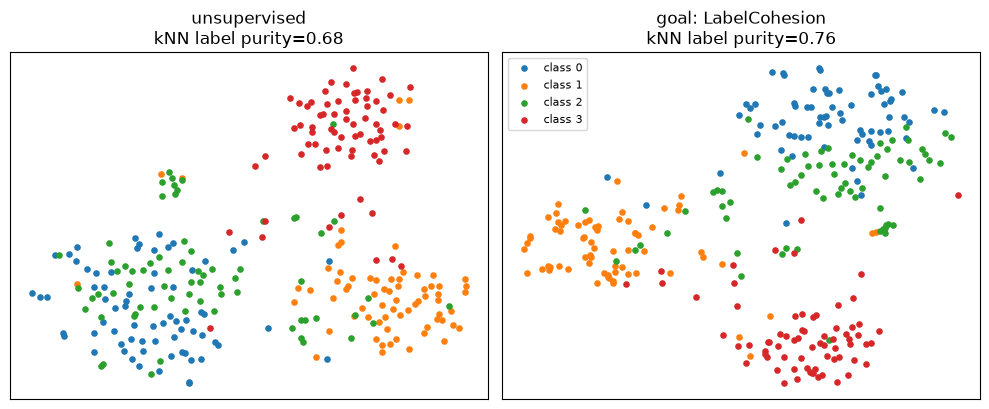

label purity : 0.676 (unsupervised) -> 0.761 (goal-guided)
fidelity     : trust 0.950 -> 0.950, continuity 0.948 -> 0.947  (guidance did not distort the geometry)


In [8]:
from mixle.utils.hvis import LabelCohesion
from mixle.stats import DiagonalGaussianEstimator
from mixle.inference.estimation import optimize as _optimize
from sklearn.neighbors import NearestNeighbors

rng = np.random.RandomState(0)
K, per, D = 4, 70, 6
centers = rng.randn(K, D) * 1.3
ov_data = [(centers[k] + rng.randn(D) * 1.5).tolist() for k in range(K) for _ in range(per)]   # heavy overlap
ov_labels = np.array([k for k in range(K) for _ in range(per)])
ov_mix = _optimize(ov_data, MixtureEstimator([DiagonalGaussianEstimator(dim=D)] * K),
                   max_its=40, rng=np.random.RandomState(0), out=io.StringIO())

def knn_purity(Y, lab, k=10):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)[:, 1:]
    return float(np.mean([(lab[idx[i]] == lab[i]).mean() for i in range(len(lab))]))

Y_free = htsne(ov_data, seed=1, perplexity=30, mix_model=ov_mix, out=io.StringIO())
Y_goal = htsne(ov_data, seed=1, perplexity=30, mix_model=ov_mix,
               goals=[LabelCohesion([int(l) for l in ov_labels], weight=0.5)], out=io.StringIO())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, Y, title in zip(axes, [Y_free, Y_goal], ['unsupervised', 'goal: LabelCohesion']):
    for k in range(K):
        m = ov_labels == k
        ax.scatter(Y[m, 0], Y[m, 1], s=14, label='class %d' % k)
    ax.set_title('%s\nkNN label purity=%.2f' % (title, knn_purity(Y, ov_labels)))
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(fontsize=8, loc='best'); fig.tight_layout(); plt.show()

hf, hg = embedding_health(Y_free, ov_mix, ov_data), embedding_health(Y_goal, ov_mix, ov_data)
print('label purity : %.3f (unsupervised) -> %.3f (goal-guided)'
      % (knn_purity(Y_free, ov_labels), knn_purity(Y_goal, ov_labels)))
print('fidelity     : trust %.3f -> %.3f, continuity %.3f -> %.3f  (guidance did not distort the geometry)'
      % (hf['trustworthiness'], hg['trustworthiness'], hf['continuity'], hg['continuity']))